In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kneed import KneeLocator

## Determining the Number of Components of Functional ESs

In [ ]:
cos_df = pd.read_csv('../results/functions/stratified_by_disease/biCV/cosine.tsv', sep = '\t')
evar_df = pd.read_csv('../results/functions/stratified_by_disease/biCV/evar.tsv', sep = '\t')
l2norm_df = pd.read_csv('../results/functions/stratified_by_disease/biCV/l2norm.tsv', sep = '\t')
reco_df = pd.read_csv('../results/functions/stratified_by_disease/biCV/reconstruction_error.tsv', sep = '\t')

In [22]:
fold_n = 9
TOPICS = [i for i in range(2,21)]

In [23]:
def get_mean_metric(metric):
    fold_metric = {f:[] for f in range(1, fold_n+1)}
    for f in range(1, fold_n + 1):
        metric_mean_lst = []
        metric_std_lst = []

        for k in TOPICS:
            metric_df = metric[
                (metric['fold'] == f) &
                (metric['rank'] == k) &
                (metric['block'] == 'A') # value from A - this is validation block from biCV
            ]

            metric_mean_lst.append(metric_df['value'].mean())
            metric_std_lst.append(metric_df['value'].std())

        fold_metric[f].append(np.array(metric_mean_lst))
        fold_metric[f].append(np.array(metric_std_lst))

    return fold_metric

In [24]:
cos_folds = get_mean_metric(cos_df)
evar_folds = get_mean_metric(evar_df)
l2norm_folds = get_mean_metric(l2norm_df)
reco_folds = get_mean_metric(reco_df)

In [ ]:
def kneed_loc_combined(x, metrics_dict, fold_n, curve='concave', direction='increasing'):
    n_metrics = len(metrics_dict)

    fig, axes = plt.subplots(n_metrics, 1, figsize=(8, 4 * n_metrics), sharex=True)
    fig.suptitle("Evaluation metrics across number of components", fontsize=14)
    
    for idx, (metric_name, metric_folds) in enumerate(metrics_dict.items()):
        # Calculate mean and std across folds
        y_list = []
        for f in range(1, fold_n + 1):
            metric_per_fold = metric_folds[f][0]
            y_list.append(np.array(metric_per_fold))
        
        y_mean = np.mean(y_list, axis=0)
        y_std = np.std(y_list, axis=0)
        
        x = np.array(x)

        # Polynomial fitting (degree=4)
        coefficients = np.polyfit(x, y_mean, 4)
        x_smooth = np.linspace(x.min(), x.max(), 100)
        y_smooth = np.polyval(coefficients, x_smooth)
        
        # Detect the Knee
        kneedle_original = KneeLocator(x, y_mean, S=1.0, curve=curve, direction=direction)
        kneedle_smooth = KneeLocator(x_smooth, y_smooth, S=1.0, curve=curve, direction=direction)
        
        ax = axes[idx]
        
        # Metric name
        if metric_name == "cosine_similarity":
            display_name = 'Cosine similarity'
        elif metric_name == "explained_variance":
            display_name = 'Explained variance'
        
        # Plot
        ax.errorbar(x, y_mean, yerr=y_std, fmt='o', color='blue', 
                   capsize=3, capthick=2, elinewidth=1, 
                   label='Mean ± 1 STD', alpha=0.7, markersize=8)
        
        # Plot smoothed fit
        ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, 
               label=f"Polynomial fit (degree=4)")
        
        # Knee lines
        if kneedle_original.knee is not None:
            ax.axvline(x=kneedle_original.knee, color='b', linestyle='--', 
                       linewidth=2, label='Original knee')
        if kneedle_smooth.knee is not None:
            ax.axvline(x=kneedle_smooth.knee, color='r', linestyle='--', 
                       linewidth=2, label='Smoothed knee')
        
        ax.set_xticks(x)
        ax.set_ylabel(display_name, fontsize=10)
        ax.legend(loc='best', fontsize=10)
        ax.set_title("")

    axes[-1].set_xlabel("Number of components")
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig('../images/biCV.png', dpi=300, bbox_inches='tight')
    plt.show()

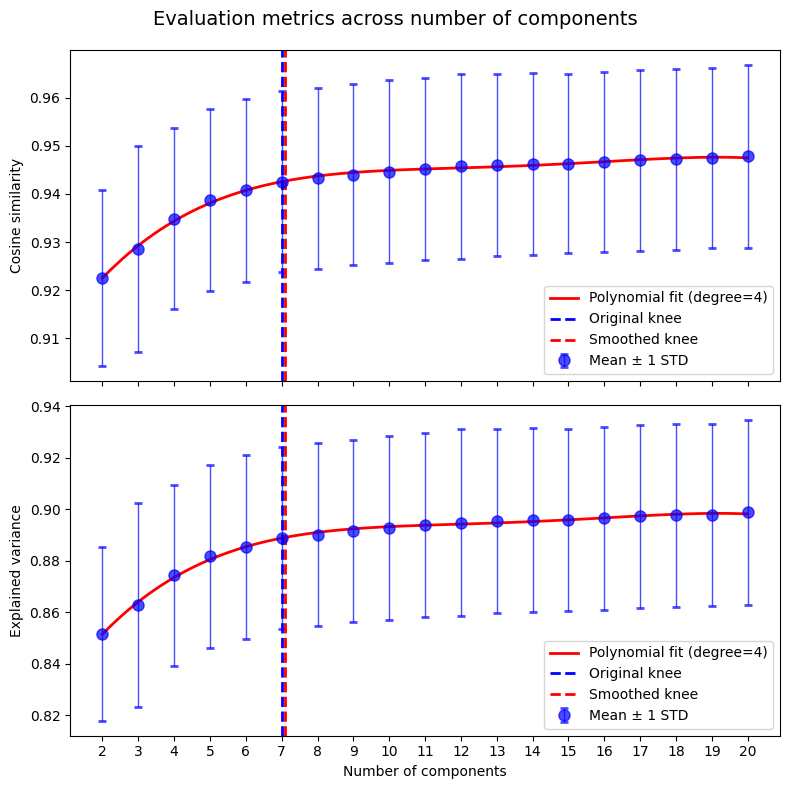

In [ ]:
topics_arr = np.array(TOPICS)
metrics_dict = {'cosine_similarity': cos_folds,
                'explained_variance': evar_folds}
kneed_loc_combined(topics_arr, metrics_dict, fold_n)